In [1]:
# install packages and download phantom
!pip install pypulseq==1.4.2post1 -q
!pip install pydisseqt>=0.1.13 -q
!pip install MRzeroCore -q
!pip install torchkbnufft --no-deps -q
!pip install ismrmrd -q
!wget https://github.com/MRsources/MRzero-Core/raw/main/documentation/playground_mr0/numerical_brain_cropped.mat -q
print('done')

done


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_PATH = '/content/drive/MyDrive/phantomnet_dataset/'
os.makedirs(SAVE_PATH, exist_ok=True)
os.makedirs(SAVE_PATH + 'checkpoints/', exist_ok=True)
print('drive ready:', SAVE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
drive ready: /content/drive/MyDrive/phantomnet_dataset/


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import MRzeroCore as mr0
import pypulseq as pp
import torch
import matplotlib.pyplot as plt
import copy, time

print(f'GPU: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name: {torch.cuda.get_device_name(0)}')

GPU: True
GPU name: Tesla T4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
def build_flash_sequence(Nread=64, Nphase=64, fov=(200e-3, 200e-3, 8e-3)):
    # FLASH sequence — T2* sensitive, same class as clinical SWI
    # at TE=15ms hemosiderin (T2*=2ms) loses almost all signal,
    # normal brain (T2*=30ms) keeps ~60% — that is where the dark spot comes from
    system = pp.Opts(
        max_grad=28,   grad_unit='mT/m',
        max_slew=150,  slew_unit='T/m/s',
        rf_ringdown_time=20e-6,
        rf_dead_time=100e-6,
        adc_dead_time=20e-6,
        grad_raster_time=10e-6
    )

    seq       = pp.Sequence()
    fov_x, fov_y, slice_thickness = fov
    flip_angle = 10 * np.pi / 180
    dwell_time = 10e-5

    rf1, _, _ = pp.make_sinc_pulse(
        flip_angle      = flip_angle,
        duration        = 1e-3,
        slice_thickness = slice_thickness,
        apodization     = 0.5,
        time_bw_product = 4,
        system          = system,
        return_gz       = True
    )

    gx = pp.make_trapezoid(
        channel   = 'x',
        flat_area = Nread / fov_x,
        flat_time = Nread * dwell_time,
        system    = system
    )

    adc = pp.make_adc(
        num_samples  = Nread,
        duration     = Nread * dwell_time,
        phase_offset = 0,
        delay        = gx.rise_time,
        system       = system
    )

    gx_pre = pp.make_trapezoid(
        channel  = 'x',
        area     = -gx.area / 2,
        duration = 1e-3,
        system   = system
    )

    gx_spoil = pp.make_trapezoid(
        channel  = 'x',
        area     = 1.5 * gx.area,
        duration = 2e-3,
        system   = system
    )

    rf_phase        = 0
    rf_inc          = 0
    rf_spoiling_inc = 117

    phenc       = np.arange(-Nphase // 2, Nphase // 2, 1) / fov_y
    permvec     = np.arange(0, Nphase, 1)
    phenc_centr = phenc[permvec]

    for ii in range(Nphase):
        rf1.phase_offset = rf_phase / 180 * np.pi
        adc.phase_offset = rf_phase / 180 * np.pi
        rf_inc   = divmod(rf_inc + rf_spoiling_inc, 360.0)[1]
        rf_phase = divmod(rf_phase + rf_inc, 360.0)[1]

        seq.add_block(rf1)
        gp = pp.make_trapezoid(channel='y', area=phenc_centr[ii],  duration=1e-3, system=system)
        seq.add_block(gx_pre, gp)
        seq.add_block(adc, gx)
        gp = pp.make_trapezoid(channel='y', area=-phenc_centr[ii], duration=1e-3, system=system)
        seq.add_block(gx_spoil, gp)

    # mrzero cannot take a pypulseq object directly — write to .seq then reimport
    seq.write('flash.seq')
    seq_mr0 = mr0.Sequence.import_file('flash.seq')

    print(f'sequence built: {Nread}x{Nphase}')
    return seq_mr0, permvec


seq_mr0, permvec = build_flash_sequence(Nread=64, Nphase=64)

/tmp/ipykernel_32630/2599970695.py:19: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf1, _, _ = pp.make_sinc_pulse(
/tmp/ipykernel_32630/2599970695.py:36: UserWarning: Specified ADC delay 10.00 us is less than the dead time 20 us. Delay was increased to the dead time.
  adc = pp.make_adc(


sequence built: 64x64


In [5]:
def load_base_phantom(size=64):
    obj_p = mr0.VoxelGridPhantom.load_mat('numerical_brain_cropped.mat')
    obj_p = obj_p.interpolate(size, size, 1)

    # setting T2* uniformly to 30ms — roughly correct for healthy brain at 3T
    obj_p.T2dash[:] = 30e-3
    # NOTE: do NOT zero diffusion. D is the primary discriminator
    # between WML (D unchanged ~0.7e-9) and AMI (D restricted to 0.05e-9).
    # Zeroing D makes those two classes inseparable in k-space.
    obj_p.D[:] = 0.7e-9   # realistic baseline brain ADC ~0.7 um2/ms

    print(f'phantom shape: {obj_p.PD.shape}')
    print(f'T2dash: {obj_p.T2dash.min()*1000:.1f}ms to {obj_p.T2dash.max()*1000:.1f}ms')
    return obj_p


phantom_base = load_base_phantom(size=64)

phantom shape: torch.Size([64, 64, 1])
T2dash: 30.0ms to 30.0ms


In [6]:
def add_microbleed(phantom, center_voxel, radius_voxels=3):
    # hemosiderin T2*=2ms, normal brain is 30ms — 15x shorter, very dark on GRE
    # B0 distortion at edges replicates SWI blooming artifact
    mb    = copy.deepcopy(phantom)
    shape = mb.T2dash.shape
    cx, cy = center_voxel[0], center_voxel[1]

    x  = torch.arange(shape[0], dtype=torch.float32)
    y  = torch.arange(shape[1], dtype=torch.float32)
    xx, yy = torch.meshgrid(x, y, indexing='ij')

    dist_sq   = (xx - cx)**2 + (yy - cy)**2
    core_mask = dist_sq <= radius_voxels**2
    edge_mask = (dist_sq <= (radius_voxels + 1.5)**2) & ~core_mask

    brain_mask = mb.PD[:, :, 0] > 0.1
    core_mask  = core_mask & brain_mask
    edge_mask  = edge_mask & brain_mask

    if core_mask.sum() == 0:
        return None, False

    mb.T2dash[core_mask, 0] = 0.002   # 2ms hemosiderin T2*
    mb.T2[core_mask, 0]     = 0.010   # 10ms T2
    mb.PD[core_mask, 0]     = mb.PD[core_mask, 0] * 0.5
    mb.B0[edge_mask, 0]     = mb.B0[edge_mask, 0] + 30.0

    return mb, True


# quick sanity check
test_mb, ok = add_microbleed(phantom_base, (32, 32, 0), radius_voxels=3)
print(f'microbleed placed: {ok}')
print(f'normal T2dash: {phantom_base.T2dash[32,32,0]*1000:.1f}ms')
print(f'bleed  T2dash: {test_mb.T2dash[32,32,0]*1000:.1f}ms')
print(f'contrast: {phantom_base.T2dash[32,32,0]/test_mb.T2dash[32,32,0]:.0f}x')

microbleed placed: True
normal T2dash: 30.0ms
bleed  T2dash: 2.0ms
contrast: 15x


In [7]:
def add_white_matter_lesion(phantom, center_voxel, radius_voxels=7):
    # white matter lesions are demyelination/gliosis patches
    # key difference from microbleeds: no iron, so T2* is LONGER not shorter
    # they appear bright on T2, not dark — opposite contrast to microbleeds
    # larger than microbleeds: typically 5-15mm so radius 5-10 voxels
    mb    = copy.deepcopy(phantom)
    shape = mb.T2dash.shape
    cx, cy = center_voxel[0], center_voxel[1]

    x  = torch.arange(shape[0], dtype=torch.float32)
    y  = torch.arange(shape[1], dtype=torch.float32)
    xx, yy = torch.meshgrid(x, y, indexing='ij')

    dist_sq   = (xx - cx)**2 + (yy - cy)**2
    core_mask = dist_sq <= radius_voxels**2

    # WML sits in white matter — WM has PD ~0.6-0.75 in this phantom
    # using PD range as a rough WM selector
    wm_mask   = (mb.PD[:, :, 0] > 0.55) & (mb.PD[:, :, 0] < 0.85)
    core_mask = core_mask & wm_mask

    if core_mask.sum() == 0:
        return None, False

    # T2* prolonged (brighter), T2 very prolonged, T1 prolonged, PD elevated
    # no B0 distortion — no iron in WML unlike microbleeds
    mb.T2dash[core_mask, 0] = 0.080   # 80ms — longer than normal 30ms (brighter)
    mb.T2[core_mask, 0]     = 0.150   # 150ms — vs ~75ms normal WM (hallmark signal)
    mb.T1[core_mask, 0]     = 1.200   # 1200ms — vs ~830ms normal WM
    mb.PD[core_mask, 0]     = mb.PD[core_mask, 0] * 1.1  # slightly elevated

    return mb, True


# sanity check
test_wml, ok = add_white_matter_lesion(phantom_base, (32, 32, 0), radius_voxels=7)
print(f'WML placed: {ok}')
if ok:
    # Find a voxel within the radius that was actually modified
    shape = phantom_base.T2dash.shape
    x  = torch.arange(shape[0], dtype=torch.float32)
    y  = torch.arange(shape[1], dtype=torch.float32)
    xx, yy = torch.meshgrid(x, y, indexing='ij')
    dist_sq   = (xx - 32)**2 + (yy - 32)**2
    core_mask = dist_sq <= 7**2
    wm_mask   = (phantom_base.PD[:, :, 0] > 0.55) & (phantom_base.PD[:, :, 0] < 0.85)
    core_mask = core_mask & wm_mask
    indices = torch.nonzero(core_mask)
    if len(indices) > 0:
        vx, vy = indices[0][0].item(), indices[0][1].item()
        print(f'WML checked at voxel ({vx}, {vy}, 0):')
        print(f'  WML T2dash: {test_wml.T2dash[vx,vy,0]*1000:.1f}ms  (normal: {phantom_base.T2dash[vx,vy,0]*1000:.1f}ms)')
        print(f'  WML T2:     {test_wml.T2[vx,vy,0]*1000:.1f}ms  (normal: {phantom_base.T2[vx,vy,0]*1000:.1f}ms)')
    else:
        print('No white matter voxels found within lesion radius!')


WML placed: True
WML T2dash: 30.0ms  (normal: 30.0ms)
WML T2:     522.2ms  (normal: 522.2ms)


In [8]:
def add_acute_microinfarct(phantom, center_voxel, radius_voxels=2):
    # acute microinfarcts are tiny ischemic strokes with cytotoxic edema
    # similar size to microbleeds (1-4mm) but very different tissue properties
    # edema = water accumulation = long T1, long T2, elevated PD
    # T2* only slightly elevated (no iron) — mainly T2 prolongation distinguishes them
    mb    = copy.deepcopy(phantom)
    shape = mb.T2dash.shape
    cx, cy = center_voxel[0], center_voxel[1]

    x  = torch.arange(shape[0], dtype=torch.float32)
    y  = torch.arange(shape[1], dtype=torch.float32)
    xx, yy = torch.meshgrid(x, y, indexing='ij')

    dist_sq   = (xx - cx)**2 + (yy - cy)**2
    core_mask = dist_sq <= radius_voxels**2
    edge_mask = (dist_sq <= (radius_voxels + 1.0)**2) & ~core_mask

    # can be in either gray or white matter — just needs actual brain tissue
    brain_mask = mb.PD[:, :, 0] > 0.1
    core_mask  = core_mask & brain_mask
    edge_mask  = edge_mask & brain_mask

    if core_mask.sum() == 0:
        return None, False

    # edema tissue properties — water replaces normal tissue
    mb.T2dash[core_mask, 0] = 0.050   # 50ms — slightly above normal 30ms
    mb.T2[core_mask, 0]     = 0.200   # 200ms — very prolonged due to edema
    mb.T1[core_mask, 0]     = 1.500   # 1500ms — prolonged, acute ischemia
    mb.PD[core_mask, 0]     = mb.PD[core_mask, 0] * 1.2  # elevated, edema
    mb.D[core_mask, 0]      = 0.05e-9  # Restricted diffusion (cytotoxic edema)
    mb.B0[edge_mask, 0]     = mb.B0[edge_mask, 0] + 10.0  # minor susceptibility

    return mb, True


# sanity check
test_ami, ok = add_acute_microinfarct(phantom_base, (28, 40, 0), radius_voxels=2)
print(f'AMI placed: {ok}')
if ok:
    print(f'AMI T2dash: {test_ami.T2dash[28,40,0]*1000:.1f}ms  (normal: {phantom_base.T2dash[28,40,0]*1000:.1f}ms)')
    print(f'AMI T2:     {test_ami.T2[28,40,0]*1000:.1f}ms  (normal: {phantom_base.T2[28,40,0]*1000:.1f}ms)')


AMI placed: True
AMI T2dash: 50.0ms  (normal: 30.0ms)
AMI T2:     200.0ms  (normal: 91.4ms)


In [9]:
def simulate_kspace(phantom, seq_mr0, Nread=64, Nphase=64, permvec=None):
    # runs the bloch simulation — most expensive step
    obj    = phantom.build()
    graph  = mr0.compute_graph(seq_mr0, obj, 200, 1e-3)
    signal = mr0.execute_graph(graph, seq_mr0, obj, print_progress=False)

    # signal comes out 1D, reshape to (phase, read) then transpose
    kspace = torch.reshape(signal, (Nphase, Nread)).clone().t()

    if permvec is not None:
        ipermvec = np.argsort(permvec)
        kspace   = kspace[:, ipermvec]

    return kspace.numpy()  # complex64, (64, 64)


def reconstruct(kspace):
    spectrum = torch.fft.fftshift(torch.tensor(kspace))
    space    = torch.fft.fft2(spectrum)
    space    = torch.fft.ifftshift(space)
    return np.abs(space.numpy())

print('simulate_kspace and reconstruct ready')

simulate_kspace and reconstruct ready


simulating all 4 classes...
healthy done (2.3s)
microbleed done (2.3s)
WML done (1.3s)
AMI done (1.3s)


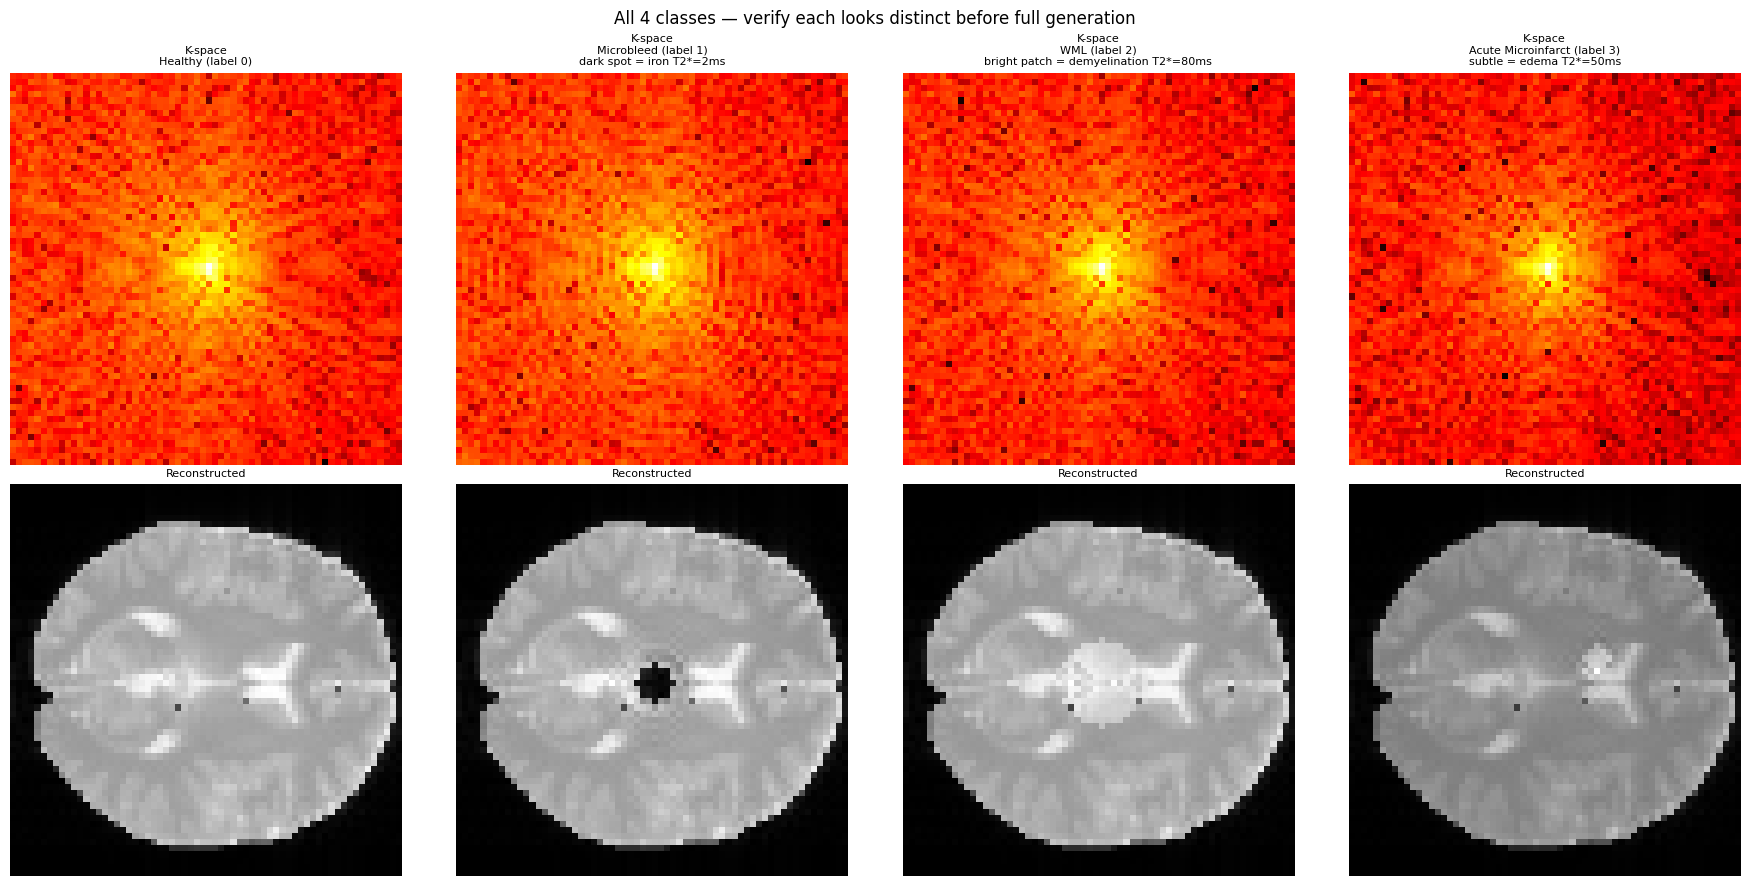

check:
  label 1 (microbleed) — dark circular spot
  label 2 (WML)        — bright/lighter patch, larger area
  label 3 (AMI)        — subtle small change
if these look different from healthy and from each other, proceed to generation


In [10]:
# run one sample per class to visually verify all 4 look different
import time

print('simulating all 4 classes...')
t0 = time.time()

ks_healthy = simulate_kspace(phantom_base, seq_mr0, permvec=permvec)
print(f'healthy done ({time.time()-t0:.1f}s)')

t0 = time.time()
ks_mb = simulate_kspace(test_mb, seq_mr0, permvec=permvec)
print(f'microbleed done ({time.time()-t0:.1f}s)')

t0 = time.time()
ks_wml = simulate_kspace(test_wml, seq_mr0, permvec=permvec)
print(f'WML done ({time.time()-t0:.1f}s)')

t0 = time.time()
ks_ami = simulate_kspace(test_ami, seq_mr0, permvec=permvec)
print(f'AMI done ({time.time()-t0:.1f}s)')

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
samples = [
    (ks_healthy, 'Healthy (label 0)'),
    (ks_mb,      'Microbleed (label 1)\ndark spot = iron T2*=2ms'),
    (ks_wml,     'WML (label 2)\nbright patch = demyelination T2*=80ms'),
    (ks_ami,     'Acute Microinfarct (label 3)\nsubtle = edema T2*=50ms'),
]

for col, (ks, title) in enumerate(samples):
    axes[0][col].imshow(np.log(np.abs(ks) + 1e-9), cmap='hot')
    axes[0][col].set_title(f'K-space\n{title}', fontsize=8)
    axes[0][col].axis('off')
    axes[1][col].imshow(reconstruct(ks), cmap='gray')
    axes[1][col].set_title('Reconstructed', fontsize=8)
    axes[1][col].axis('off')

plt.suptitle('All 4 classes — verify each looks distinct before full generation')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'class_verification.png', dpi=150)
plt.show()

print('check:')
print('  label 1 (microbleed) — dark circular spot')
print('  label 2 (WML)        — bright/lighter patch, larger area')
print('  label 3 (AMI)        — subtle small change')
print('if these look different from healthy and from each other, proceed to generation')


In [12]:
from tqdm import tqdm

# labels:
#   0 = healthy        -> 1200 samples
#   1 = microbleed     ->  600 samples
#   2 = white matter lesion (WML) ->  600 samples
#   3 = acute microinfarct  (AMI) ->  600 samples
#
# total: 3000 samples (2:1 healthy-to-disease ratio)
# each sample has exactly ONE pathology — no mixing, clean labels

def generate_one_class(label, n_samples, phantom_base, seq_mr0, permvec,
                        save_path, margin=15, checkpoint_every=100):
    shape = phantom_base.PD.shape
    X, y  = [], []
    i     = 0

    label_names = {0: 'healthy', 1: 'microbleed', 2: 'WML', 3: 'AMI'}
    print(f"\ngenerating {n_samples} x {label_names[label]} (label={label})")
    t0 = time.time()

    with tqdm(total=n_samples) as pbar:
        while i < n_samples:

            if label == 0:
                # healthy — use base phantom as is
                try:
                    k = simulate_kspace(phantom_base, seq_mr0, permvec=permvec)
                    X.append(k); y.append(0)
                    i += 1; pbar.update(1)
                except Exception as e:
                    print(f'healthy sim error: {e}'); continue

            elif label == 1:
                # microbleed — random location, small radius
                placed = False
                for _ in range(30):
                    cx = np.random.randint(margin, shape[0]-margin)
                    cy = np.random.randint(margin, shape[1]-margin)
                    r  = np.random.randint(2, 5)
                    mb_phantom, placed = add_microbleed(phantom_base, (cx,cy,0), r)
                    if placed: break
                if not placed: continue
                try:
                    k = simulate_kspace(mb_phantom, seq_mr0, permvec=permvec)
                    X.append(k); y.append(1)
                    i += 1; pbar.update(1)
                except Exception as e:
                    print(f'microbleed sim error: {e}'); continue

            elif label == 2:
                # WML — larger radius, placed in white matter region
                placed = False
                for _ in range(30):
                    cx = np.random.randint(margin, shape[0]-margin)
                    cy = np.random.randint(margin, shape[1]-margin)
                    r  = np.random.randint(5, 11)  # 5-10 voxel radius
                    wml_phantom, placed = add_white_matter_lesion(phantom_base, (cx,cy,0), r)
                    if placed: break
                if not placed: continue
                try:
                    k = simulate_kspace(wml_phantom, seq_mr0, permvec=permvec)
                    X.append(k); y.append(2)
                    i += 1; pbar.update(1)
                except Exception as e:
                    print(f'WML sim error: {e}'); continue

            elif label == 3:
                # AMI — small radius, anywhere in brain tissue
                # D=0.05e-9 in add_acute_microinfarct is the key discriminator from WML
                placed = False
                for _ in range(30):
                    cx = np.random.randint(margin, shape[0]-margin)
                    cy = np.random.randint(margin, shape[1]-margin)
                    r  = np.random.randint(1, 4)  # 1-3 voxel radius
                    ami_phantom, placed = add_acute_microinfarct(phantom_base, (cx,cy,0), r)
                    if placed: break
                if not placed: continue
                try:
                    k = simulate_kspace(ami_phantom, seq_mr0, permvec=permvec)
                    X.append(k); y.append(3)
                    i += 1; pbar.update(1)
                except Exception as e:
                    print(f'AMI sim error: {e}'); continue

            # mid-class checkpoint every checkpoint_every samples
            if i > 0 and i % checkpoint_every == 0:
                np.save(f'{save_path}checkpoints/X_class{label}_{i:04d}.npy', np.array(X))
                np.save(f'{save_path}checkpoints/y_class{label}_{i:04d}.npy', np.array(y))
                elapsed = (time.time() - t0) / 60
                rem     = (elapsed / i) * (n_samples - i)
                print(f'  [{label_names[label]}] {i}/{n_samples} | {elapsed:.1f}min | ~{rem:.1f}min left')

    return np.array(X), np.array(y)


def generate_dataset(n_healthy=1200, n_microbleed=600, n_wml=600, n_ami=600,
                     save_path=SAVE_PATH):
    """
    Generates an unequal-class dataset:
      1200 healthy, 600 microbleed, 600 WML, 600 AMI  =  3000 total

    2:1 healthy-to-disease ratio is intentional — it reflects real clinical
    prevalence and prevents the model from being biased toward pathology.

    Each class is generated and checkpointed independently so a Colab
    timeout only loses the current class, not the entire run.
    """
    counts = {0: n_healthy, 1: n_microbleed, 2: n_wml, 3: n_ami}
    names  = {0: 'healthy', 1: 'microbleed', 2: 'WML', 3: 'AMI'}
    total  = sum(counts.values())

    print(f"Dataset target:")
    for cls, n in counts.items():
        print(f"  class {cls} ({names[cls]}): {n} samples")
    print(f"  TOTAL: {total} samples")

    start   = time.time()
    all_X, all_y = [], []

    for label, n in counts.items():
        X_cls, y_cls = generate_one_class(
            label, n, phantom_base, seq_mr0, permvec, save_path
        )
        all_X.append(X_cls)
        all_y.append(y_cls)

        # final per-class checkpoint
        np.save(f'{save_path}checkpoints/X_class{label}_final.npy', X_cls)
        np.save(f'{save_path}checkpoints/y_class{label}_final.npy', y_cls)
        elapsed = (time.time() - start) / 60
        print(f'class {label} ({names[label]}) done — {elapsed:.1f}min total so far')

    X_arr = np.concatenate(all_X, axis=0)
    y_arr = np.concatenate(all_y, axis=0)

    # shuffle so classes are interleaved in the final file
    idx   = np.random.permutation(len(X_arr))
    X_arr = X_arr[idx]
    y_arr = y_arr[idx]

    np.save(save_path + 'kspace_X_final.npy', X_arr)
    np.save(save_path + 'kspace_y_final.npy', y_arr)

    total_min = (time.time() - start) / 60
    print(f'\n=== DONE in {total_min:.1f} min ===')
    print(f'Final shape:   {X_arr.shape}  |  dtype: {X_arr.dtype}')
    for cls, name in names.items():
        print(f'  {name:12s}: {sum(y_arr==cls)}')
    print(f'  {"TOTAL":12s}: {len(y_arr)}')
    return X_arr, y_arr


X, y = generate_dataset(n_healthy=1200, n_microbleed=600, n_wml=600, n_ami=600)


Dataset target:
  class 0 (healthy): 1200 samples
  class 1 (microbleed): 600 samples
  class 2 (WML): 600 samples
  class 3 (AMI): 600 samples
  TOTAL: 3000 samples

generating 1200 x healthy (label=0)


  8%|▊         | 100/1200 [02:14<24:45,  1.35s/it]

  [healthy] 100/1200 | 2.2min | ~24.7min left


 17%|█▋        | 200/1200 [04:29<22:19,  1.34s/it]

  [healthy] 200/1200 | 4.5min | ~22.4min left


...

  [AMI] 400/600 | 9.0min | ~4.5min left


 83%|████████▎ | 500/600 [11:21<02:15,  1.36s/it]

  [AMI] 500/600 | 11.4min | ~2.3min left


100%|██████████| 600/600 [13:43<00:00,  1.37s/it]


  [AMI] 600/600 | 13.7min | ~0.0min left
class 3 (AMI) done — 66.9min total so far

=== DONE in 66.9 min ===
Final shape:   (3000, 64, 64)  |  dtype: complex64
  healthy     : 1200
  microbleed  : 600
  WML         : 600
  AMI         : 600
  TOTAL       : 3000


DATASET SUMMARY
  shape      : (3000, 64, 64)
  dtype      : complex64
  is complex : True
  healthy    : 1200
  microbleed : 600
  WML        : 600
  AMI        : 600
  size X     : 98.3 MB
  size y     : 24.0 KB


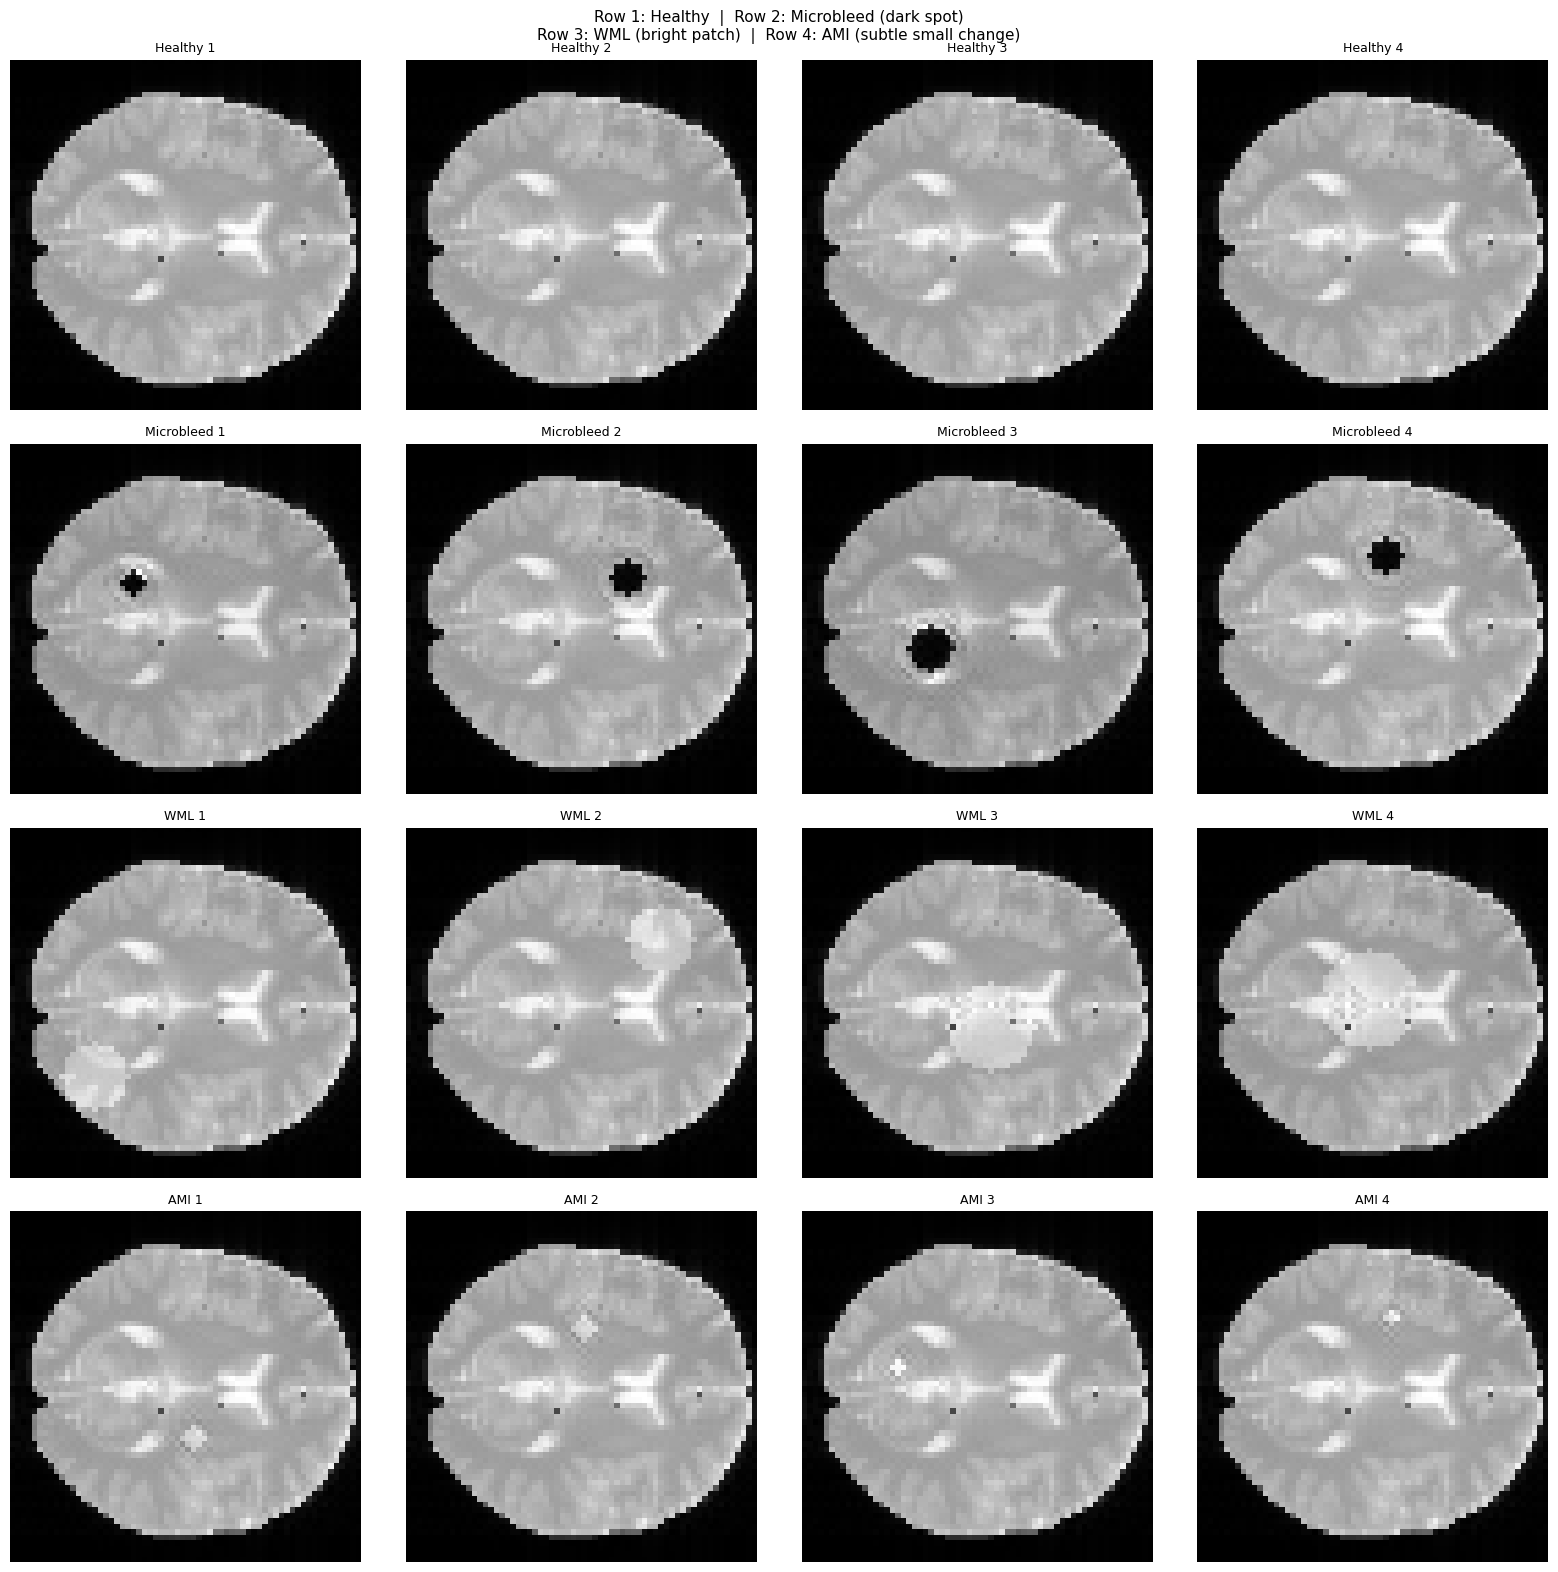


for pytorch training:
  X_2ch = np.stack([X.real, X.imag], axis=1)  # (N, 2, 64, 64)
  labels: 0=healthy, 1=microbleed, 2=WML, 3=AMI


In [13]:
X = np.load(SAVE_PATH + 'kspace_X_final.npy')
y = np.load(SAVE_PATH + 'kspace_y_final.npy')

print('DATASET SUMMARY')
print(f'  shape      : {X.shape}')
print(f'  dtype      : {X.dtype}')
print(f'  is complex : {np.iscomplexobj(X)}')
print(f'  healthy    : {sum(y==0)}')
print(f'  microbleed : {sum(y==1)}')
print(f'  WML        : {sum(y==2)}')
print(f'  AMI        : {sum(y==3)}')
print(f'  size X     : {X.nbytes/1e6:.1f} MB')
print(f'  size y     : {y.nbytes/1e3:.1f} KB')

label_names = {0:'Healthy', 1:'Microbleed', 2:'WML', 3:'AMI'}
label_colors = {0:'white', 1:'red', 2:'yellow', 3:'cyan'}

fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for row, label in enumerate([0, 1, 2, 3]):
    idxs = np.where(y == label)[0][:4]
    for col, idx in enumerate(idxs):
        img = reconstruct(X[idx])
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].set_title(f'{label_names[label]} {col+1}', fontsize=9)
        axes[row][col].axis('off')

plt.suptitle(
    'Row 1: Healthy  |  Row 2: Microbleed (dark spot)\n'
    'Row 3: WML (bright patch)  |  Row 4: AMI (subtle small change)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'final_verification.png', dpi=150)
plt.show()

print('\nfor pytorch training:')
print('  X_2ch = np.stack([X.real, X.imag], axis=1)  # (N, 2, 64, 64)')
print('  labels: 0=healthy, 1=microbleed, 2=WML, 3=AMI')
